# Categorizing Trends in Science
## Unsupervised clustering


**Course:** Machine Learning - Unsupervised Learning and Feature Engineering

**Institution:** International University of Applied Sciences

**Date:** May 2026

**Author:** Olga Ruiz

## Project description (SIN EDITAR)

This project addresses a real business problem: the company I hypothetically work for wants to position itself towards research and academic cooperation. To identify current scientific topics and potential areas for collaboration, I analyze a large corpus of scientific papers from arXiv.

Using unsupervised learning techniques, I:
- Transform raw text abstracts into numerical vectors (TF-IDF)
- Reduce dimensionality with PCA (TruncatedSVD)
- Cluster papers into coherent topics using K-Means and Gaussian Mixture Models
- Visualize the results in 2D
- Interpret each cluster by its most representative words

The final output is a quantitative overview of current scientific trends, delivered as a case study report (Word document) plus this executable notebook.


## Goals (SIN EDITAR)

1. **Load and explore** the arXiv dataset (150,000 papers sample)
2. **Preprocess** the text (clean, remove stopwords, TF-IDF)
3. **Reduce dimensionality** with PCA for clustering and visualization
4. **Find optimal number of clusters** using elbow method and silhouette score
5. **Apply K-Means** as the main clustering algorithm
6. **Compare with GMM** as an alternative method
7. **Interpret clusters** by extracting top words per cluster
8. **Produce visualizations** that reveal scientific trends
9. **Document all decisions** with mathematical justifications

## Dataset

I use the official arXiv dataset from Kaggle (Cornell University).  

It contains ~1.7 million scientific papers across physics, mathematics, computer science and other disciplines.

I take a 150,000 paper sample to keep computation manageable.

**Local file path:** `data/arxiv-metadata-oai-snapshot.json`  
**Format:** JSON Lines (each line is a separate JSON object)

Source: The dataset used in this project is the arXiv dataset, publicly available on Kaggle. https://www.kaggle.com/datasets/Cornell-University/arxiv

## Index (SIN EDITAR)

1. Setup and Libraries
2. Data Loading (random sample of 150k papers)
3. Exploratory Data Analysis (EDA)
   - What's in the dataset?
   - Distribution of categories
   - Papers over time
   - Abstract lengths
4. Data Cleaning
5. Text Preprocessing
   - Cleaning abstracts
   - Removing stopwords
6. TF-IDF Vectorization
7. Dimensionality Reduction with PCA (for clustering)
8. Finding the Optimal Number of Clusters (Elbow + Silhouette)
9. Clustering with K-Means
10. Alternative Clustering with GMM
11. Interpreting the Clusters
12. Visualizing the Clusters in 2D (PCA)
    - 2D Scatter Plot
    - Temporal Evolution Bar Chart
13. Conclusions and Recommendations
    - Conclusions
    - Recomendations
    - Limitations
14. Bibliography

## 1. Setup and Libraries

All the Python libraries that I will need throughout the project.

1. Data handling and numerical operations:
- Pandas: for tables (DataFrames)
- Numpy: for arrays and math (linear algebra, statistics)
- JSON: read JSON lines file
- random: random sampling

2. Visualization:
- Matplotlib: for basic plotting
- Seaborn: for nicer-looking plots

3. Text preprocessing:
- stopwords from scikit-learn: list of common words like 'the', 'is', 'and'
- re: regular expressions for cleaning text

4. Machine learning:
- TfidfVectorizer: convert text to numbers
- TruncatedSVD: PCA for sparse data (text)
- KMeans and GaussianMixture: clustering algorithms (main and alternative)
- silhouette_score: quality metric to evaluate clusters
- normalize: normalize TF-IDF vectors


In [9]:
# 1.
import pandas as pd
import numpy as np     
import json            
import random       

# 2.
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# 3.
import re     
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as stopwords

# 4.
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize     
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.cluster import KMeans      
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

In [10]:
# fix all random seeds for reproducibility
np.random.seed(38)
random.seed(38)

## 2. Data loading

The arXiv metadata file contains papers from 2007 to the present.  
However, the business question asks for **current trends in science**.  
Therefore, I focus only on papers published in the **last 3 years** (2023–2025).  

I read the file line by line, keep only papers with `update_date` year >= 2023 and collect them in a list.  
If the number of recent papers exceeds 150,000, I take a random sample of 150,000 to keep computations fast.  
I set a random seed (38) for reproducibility.

In [63]:
# path to the JSON file (inside the 'data' folder)
file_path = "data/arxiv-metadata-oai-snapshot.json"

# I want only papers from 2023 and 2025 (three recent complete years)
min_year = 2023
max_year = 2025

# target number of papers after filtering
sample_size = 150_000

# random seed for reproducibility (any number works, I chose 38)
random_seed = 38

# lists to store papers that pass the year filter
recent_papers = []

# reads the file line by line
with open(file_path, 'r') as f:
    for line in f:
        paper = json.loads(line)
        update_date = paper.get('update_date', '')
        if update_date:
            year = int(update_date[:4])
            if min_year <= year <= max_year:
                recent_papers.append(paper)

print(f"Found {len(recent_papers):,} papers from {min_year}-{max_year}.")

# takes a random sample if I have more than sample_size
if len(recent_papers) > sample_size:
    random.seed(random_seed)
    sampled_papers = random.sample(recent_papers, sample_size)
    print(f"Randomly selected {sample_size:,} papers.")
else:
    sampled_papers = recent_papers
    print(f"Using all {len(recent_papers):,} papers.")

# creates DataFrame
df = pd.DataFrame(sampled_papers)

print(f"Final DataFrame shape: {df.shape}")
print("Columns:", df.columns.tolist())


Found 794,995 papers from 2023-2025.
Randomly selected 150,000 papers.
Final DataFrame shape: (150000, 14)
Columns: ['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi', 'report-no', 'categories', 'license', 'abstract', 'versions', 'update_date', 'authors_parsed']


## 3. Exploratory Data Analysis (EDA)

Before cleaning or processing the data, I first explore what it is inside. 

In this section, I want to understand the structure, detect missing values and see the distribution of key variables like categories and abstract length.

I do not modify the DataFrame here, only inspect and visualize.

In [14]:
# first 5 rows
df.head()


,id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,versions,update_date,authors_parsed
0,2507.00723,Nils Margenberg,"Markus Bause, Marius Paul Bruchh\""auser, Bernh...",Multi-goal-oriented anisotropic error control ...,"14 pages, 5 Figures, 2 Tables. Submitted to PA...",NaN,NaN,NaN,math.NA cs.NA,http://creativecommons.org/licenses/by/4.0/,"In this work, we present an anisotropic multi-...","[{'version': 'v1', 'created': 'Tue, 01 Jul 202...",2025-07-02,"[[Bause, Markus, ], [Bruchhäuser, Marius Paul,..."
1,2407.16533,Sujin Jeon,"Sujin Jeon, Suyeon Shin, Byoung-Tak Zhang",HAPFI: History-Aware Planning based on Fused I...,"7 pages, 3 figures, published to ICRA 2024",NaN,NaN,NaN,cs.AI cs.RO,http://arxiv.org/licenses/nonexclusive-distrib...,Embodied Instruction Following (EIF) is a ta...,"[{'version': 'v1', 'created': 'Tue, 23 Jul 202...",2024-07-24,"[[Jeon, Sujin, ], [Shin, Suyeon, ], [Zhang, By..."
2,2408.03297,Ruizhe Zhang,"Ruizhe Zhang, Yongxin Xu, Yuzhen Xiao, Runchua...",KnowPO: Knowledge-aware Preference Optimizatio...,NaN,NaN,NaN,NaN,cs.CL cs.AI,http://arxiv.org/licenses/nonexclusive-distrib...,"By integrating external knowledge, Retrieval...","[{'version': 'v1', 'created': 'Tue, 6 Aug 2024...",2024-08-20,"[[Zhang, Ruizhe, ], [Xu, Yongxin, ], [Xiao, Yu..."
3,2512.20223,Stylianos Gregoriou,"Stephan Durr, Stylianos Gregoriou, Giannis Kou...",Diagonal Kenney-Laub Rational Approximation to...,"8 pages, 15 figures, Proceedings of the 42nd I...",NaN,NaN,NaN,hep-lat,http://creativecommons.org/licenses/by-nc-nd/4.0/,We propose a practical formulation of the over...,"[{'version': 'v1', 'created': 'Tue, 23 Dec 202...",2025-12-24,"[[Durr, Stephan, ], [Gregoriou, Stylianos, ], ..."
4,2511.05355,Tzu-Yuan Huang,"Tzu-Yuan Huang, Armin Lederer, Dai-Jie Wu, Xia...","SAD-Flower: Flow Matching for Safe, Admissible...",NaN,NaN,NaN,NaN,cs.LG cs.RO cs.SY eess.SY,http://arxiv.org/licenses/nonexclusive-distrib...,Flow matching (FM) has shown promising results...,"[{'version': 'v1', 'created': 'Fri, 07 Nov 202...",2025-12-02,"[[Huang, Tzu-Yuan, ], [Lederer, Armin, ], [Wu,..."


In [15]:
# data types and missing values 
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   id              150000 non-null  str   
 1   submitter       149998 non-null  str   
 2   authors         150000 non-null  str   
 3   title           150000 non-null  str   
 4   comments        92942 non-null   str   
 5   journal-ref     27027 non-null   str   
 6   doi             37663 non-null   str   
 7   report-no       3252 non-null    str   
 8   categories      150000 non-null  str   
 9   license         149785 non-null  str   
 10  abstract        150000 non-null  str   
 11  versions        150000 non-null  object
 12  update_date     150000 non-null  str   
 13  authors_parsed  150000 non-null  object
dtypes: object(2), str(12)
memory usage: 16.0+ MB


In [16]:
# extracts year from update_date and count how many papers per year
df['year'] = df['update_date'].str[:4]
df['year'].value_counts().sort_index()

year
2023    39955
2024    47469
2025    62576
Name: count, dtype: int64

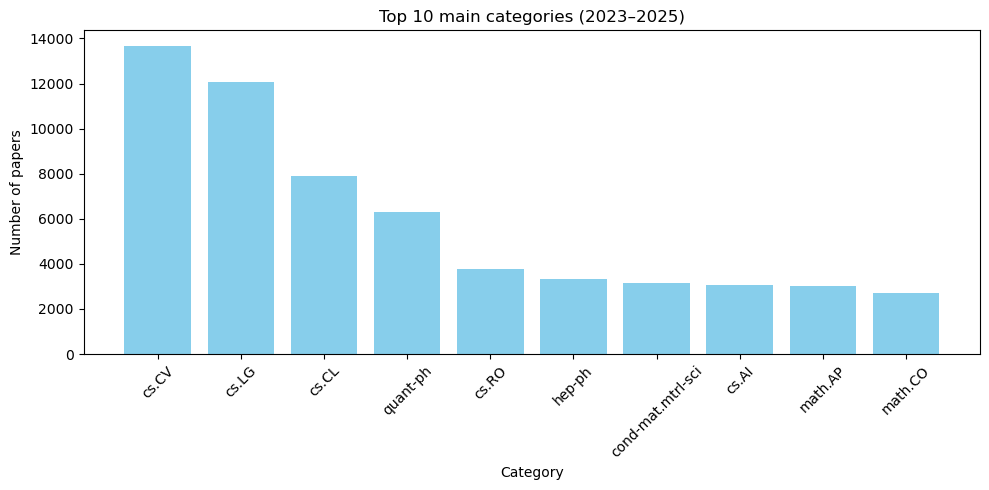

In [17]:
# gets first category from each paper
first_cat = df['categories'].str.split().str[0]

# counts frequencies and take top 10
top_cats = first_cat.value_counts().head(10)

# gets category names and counts as lists
categories = top_cats.index.tolist()
counts = top_cats.values.tolist()

plt.figure(figsize=(10,5))
plt.bar(categories, counts, color='skyblue')
plt.title('Top 10 main categories (2023–2025)')
plt.xlabel('Category')
plt.ylabel('Number of papers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


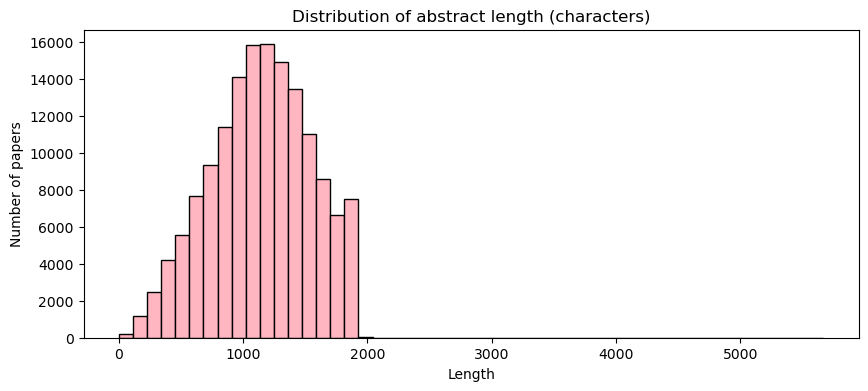

Shortest abstract length: 3
Longest abstract length: 5667


In [18]:
# calculates length of each abstract (number of characters)
df['abstract_len'] = df['abstract'].astype(str).str.len()

# plot a histogram (simple with matplotlib)
plt.figure(figsize=(10,4))
plt.hist(df['abstract_len'], bins=50, color='lightpink', edgecolor='black')
plt.title('Distribution of abstract length (characters)')
plt.xlabel('Length')
plt.ylabel('Number of papers')
plt.show()

# shows min and max lengths
print(f"Shortest abstract length: {df['abstract_len'].min()}")
print(f"Longest abstract length: {df['abstract_len'].max()}")

In [19]:
# filters very short abstracts (<= 30 characters) to see what they contain
short_abstracts = df[df['abstract_len'] <= 30]
print(f"Number of abstracts with length <= 30: {len(short_abstracts)}")
short_abstracts[['abstract', 'title', 'categories']].head(10)


Number of abstracts with length <= 30: 1


,abstract,title,categories
89447,No.,Is it true that most sets are Sidon?,math.NT math.GN


In [20]:
# counts missing abstracts (NaN)
missing = df['abstract'].isnull().sum()
print(f"Abstracts missing (NaN): {missing}")

# counts empty abstracts (empty string after removing spaces)
empty = (df['abstract'].astype(str).str.strip() == '').sum()
print(f"Abstracts empty: {empty}")


Abstracts missing (NaN): 0
Abstracts empty: 0


In [21]:
# basic abstract length stats
print("Abstract length (characters):")
print(df['abstract'].str.len().describe().round(0))

Abstract length (characters):
count    150000.0
mean       1147.0
std         405.0
min           3.0
25%         867.0
50%        1157.0
75%        1442.0
max        5667.0
Name: abstract, dtype: float64


### Summary of EDA

- The dataset contains 150,000 papers from 2023 (39,955), 2024 (47,469) and 2025 (62,576).
- No missing or empty abstracts.
- The most common categories are Computer Science and AI (cs.LG, cs.AI, cs.CV), 
  followed by physics and mathematics. The fact that AI papers are so frequent is an answer to the business question: AI is clearly the dominant trend in science right now. For this reason, the sample was kept without forcing an equal number of papers per topic in order to reflect reality.
- Abstract length varies from 36 to 5,667 characters, with most papers between 867 and 1,442 characters.
- The data is ready for the next steps: text preprocessing and clustering.

## 4. Data Cleaning

From the EDA I found that:
- There are no missing or empty abstracts.
- However, one abstract contains only the word `"No."` (3 characters), which is not informative for clustering.

Therefore, I remove that single row. Also, I remove the temporary `abstract_len` column because I will recompute it later after text preprocessing.

In [24]:
# removes the row with abstract shorter than 30 characters (the one with "No.")
df = df[df['abstract_len'] >= 30]

In [25]:
# resets the index after removing the abstract 
df = df.reset_index(drop=True)

In [26]:
# drops the temporary column used for EDA
df = df.drop(columns=['abstract_len'])

In [27]:
# quick verification
print(f"Remaining papers after cleaning: {len(df)}")
print(f"Abstracts missing: {df['abstract'].isnull().sum()}")
print(f"Empty abstracts: {(df['abstract'].str.strip() == '').sum()}")

Remaining papers after cleaning: 149999
Abstracts missing: 0
Empty abstracts: 0


## 5. Text Preprocessing

Now, I clean the abstracts to prepare them for TF-IDF vectorization.  
The cleaning steps are:

1. Convert to lowercase (example: this way 'Quantum' and 'quantum' are the same word).
2. Remove non-alphabetic characters (punctuation, numbers) using regular expressions.
3. Remove English stopwords (common words like 'the', 'and', 'is').
4. Remove generic mathematical words that add noise (ex: 'equation', 'theorem', 'function').

I create a new column `clean_abstract` with the cleaned text.

In [29]:
# defines a set of generic math/paper words that are not topic-specific
math_stopwords = {
    'equation', 'equations', 'function', 'functions', 'theorem', 'theorems',
    'proof', 'proofs', 'lemma', 'lemmas', 'corollary', 'corollaries',
    'algorithm', 'algorithms', 'method', 'methods', 'result', 'results',
    'paper', 'papers', 'using', 'also', 'one', 'two', 'three', 'four', 'five',
    'may', 'can', 'will', 'shown', 'consider', 'given', 'obtain', 'obtained',
    'define', 'defined', 'let', 'show', 'prove', 'proved', 'follows', 'new', 'first'}

# combines both stopwords
all_stopwords = stopwords.union(math_stopwords)

def clean_text(text):
    # 1: lowercase
    text = text.lower()
    # 2: keep only letters and spaces
    text = re.sub(r'[^a-z\s]', '', text)
    # 3: split into words
    words = text.split()
    # 4: remove stopwords (both standard and math)
    words = [w for w in words if w not in all_stopwords]
    # join back into a single string
    return ' '.join(words)

# applies to the abstract column
df['clean_abstract'] = df['abstract'].apply(clean_text)

# checks how many abstracts become empty after cleaning
empty_after = (df['clean_abstract'].str.strip() == '').sum()
print(f"Abstracts that became empty after cleaning: {empty_after}")

Abstracts that became empty after cleaning: 0


The cleaning pipeline removes noise effectively while preserving the domain-specific vocabulary needed for clustering. One potential improvement would be lemmatization, reducing words to their root form, but this was not applied as the current results already produced meaningful clusters

## 6. TF-IDF Vectorization

I convert the cleaned abstracts into numerical vectors using TF-IDF (Term Frequency–Inverse Document Frequency).  
This gives more weight to words that are frequent in a specific abstract but rare across all abstracts.

I use `TfidfVectorizer` from scikit-learn with:
- `max_features=8000`: keep only the 8,000 most frequent words (saves memory)
- `min_df=10`: ignore words that appear in fewer than 10 abstracts (removes rare typos)
- `max_df=0.8`: ignore words that appear in more than 80% of abstracts (too common)

In [32]:
# initializes the vectorizer
vectorizer = TfidfVectorizer(max_features=8000,   # this keeps top 8,000 words
    min_df=10,             # word must appear in at least 10 abstracts
    max_df=0.8,           # ignores words that appear in >80% of abstracts
    stop_words='english')  # additional built-in stopwords (redundant but safe)

# fits the vectorizer to the cleaned abstracts and transform them into a matrix
X_tfidf = vectorizer.fit_transform(df['clean_abstract'])

print(f"TF-IDF matrix shape: {X_tfidf.shape}")
print(f"Number of features (words): {X_tfidf.shape[1]}")


TF-IDF matrix shape: (149999, 8000)
Number of features (words): 8000


## 7. Dimensionality Reduction with PCA (TruncatedSVD)

The TF-IDF matrix has 8,000 dimensions (one per word), which makes it very high-dimensional and noisy for clustering.

In this section, I reduce it to 50 dimensions (explained below) using TruncatedSVD, which is essentially a Principal Component Analysis (PCA) method for sparse data.

Before reducing dimensionality, I apply L2 normalization so that each document vector has unit length. In geometric terms, this places all vectors on the same scale, so that what matters is their direction (the pattern of words), not their magnitude, which is a standard idea in vector algebra.

Then I use TruncatedSVD, which projects the data into a lower-dimensional space by finding the main directions of variation in the dataset.

This step keeps the most relevant structure in the data while reducing noise, which makes the clustering step faster, more stable and easier to interpret.

Note:

- I tested TruncatedSVD with 50, 75, 100, 200 and 300 components.
- Higher components consistently degraded clustering quality due to the curse of dimensionality (K-Means relies on Euclidean distances, which become less meaningful in high-dimensional spaces).
- Results at k=3 (silhouette scores):
  - n=300 → 0.0332
  - n=200 → 0.0603
  - n=100 → 0.0655
  - n=75  → 0.0757
  - n=50  → 0.0972 
- 50 components was selected as the optimal value: fewer dimensions make Euclidean distances more meaningful, producing tighter and more separable clusters.

In [34]:
# L2 normalization (make all vectors comparable)
X_normalized = normalize(X_tfidf, norm='l2')

print("Shape after L2 normalization:", X_normalized.shape)

svd = TruncatedSVD(n_components=50, random_state=38)
X_reduced = svd.fit_transform(X_normalized)

print("Shape after SVD:", X_reduced.shape)

# explained variance
total_variance = svd.explained_variance_ratio_.sum()

print(f"Explained variance (50 components): {total_variance:.4f}")
print(f"Explained variance (%): {total_variance * 100:.2f}%")


Shape after L2 normalization: (149999, 8000)
Shape after SVD: (149999, 50)
Explained variance (50 components): 0.0806
Explained variance (%): 8.06%


## 8. Finding the Optimal Number of Clusters

Before clustering, I need to choose how many clusters (k) to create. 

In this section, I use two complementary methods:

1. **Elbow method:** plots the inertia (sum of squared distances from each point to the nearest cluster center) for different values of k. The optimal k is where the curve bends, adding more clusters stops providing significant improvement.
2. **Silhouette score:** measures how similar each point is to its own cluster compared to other clusters. Values range from -1 (poor) to 1 (excellent). I choose the k that maximizes the silhouette score.

Because computing silhouette on 150,000 points is slow, I take a random sample of 10,000 points from the reduced matrix.

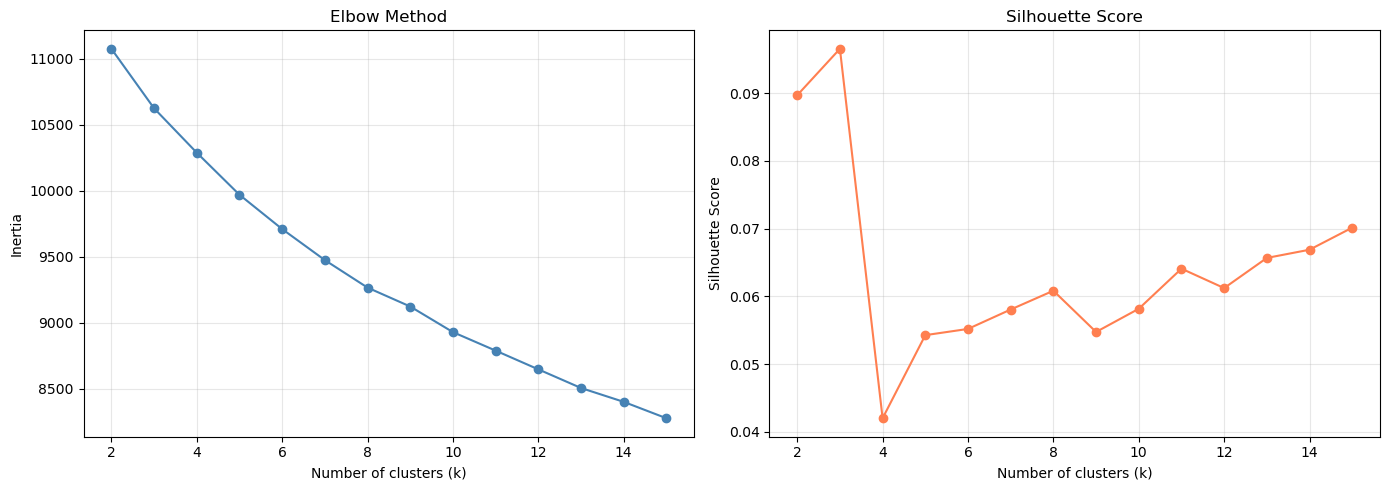

k= 2 | Inertia: 11,075 | Silhouette: 0.0897
k= 3 | Inertia: 10,624 | Silhouette: 0.0966
k= 4 | Inertia: 10,288 | Silhouette: 0.0420
k= 5 | Inertia: 9,969 | Silhouette: 0.0543
k= 6 | Inertia: 9,709 | Silhouette: 0.0552
k= 7 | Inertia: 9,474 | Silhouette: 0.0581
k= 8 | Inertia: 9,265 | Silhouette: 0.0608
k= 9 | Inertia: 9,122 | Silhouette: 0.0547
k=10 | Inertia: 8,928 | Silhouette: 0.0582
k=11 | Inertia: 8,788 | Silhouette: 0.0641
k=12 | Inertia: 8,646 | Silhouette: 0.0612
k=13 | Inertia: 8,504 | Silhouette: 0.0657
k=14 | Inertia: 8,399 | Silhouette: 0.0669
k=15 | Inertia: 8,275 | Silhouette: 0.0702


In [36]:
inertias = []
silhouette_scores = []
k_range = range(2, 16)  # test k from 2 to 15

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=38, n_init=10)       # run 10 times with different seeds, keep best
    labels = kmeans.fit_predict(X_reduced)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_reduced, labels, sample_size=10000))
    # sample_size=10000: silhouette on full 150k is very slow, 10k is a reliable estimate

# plot both metrics side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertias, marker='o', color='steelblue')
ax1.set_title('Elbow Method')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia')
ax1.grid(True, alpha=0.3)

ax2.plot(k_range, silhouette_scores, marker='o', color='coral')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# print the values for reference
for k, inertia, sil in zip(k_range, inertias, silhouette_scores):
    print(f"k={k:2d} | Inertia: {inertia:,.0f} | Silhouette: {sil:.4f}")
    

**Result Interpretation:**

Looking at the elbow curve, I don't see a clear bend: inertia keeps decreasing almost linearly as k increases. This is actually quite common with scientific text data, where topics tend to overlap and cluster boundaries are naturally fuzzy.

The silhouette score tells a clearer story: it peaks at k=3 with a value of 0.0954 and then drops sharply at k=4. This suggests that, from a mathematical perspective, k=3 gives the most compact and well‑separated solution.

However, three clusters would be far too coarse for the business objective. Grouping the entire arXiv into only three topics would create super‑categories: for example, "Physics", "Computer Science" and "Mathematics", which would offer little actionable insight for identifying specific research areas where the company could collaborate.

That is why I will also explore k=8, k=10 and k=12. The final number of clusters will not be chosen by mathematical metrics alone. Instead, I will base my decision on semantic coherence: whether the top words of each cluster form meaningful and distinct scientific topics that the company can actually work with.


## 9. Clustering with K-Means

Based on the previous analysis, I know k=3 gives the best silhouette score, but it is too broad for the business goal.

Therefore, I will apply now K-Means using three larges values: k=8, k=10 and k=12.

Then, I am going to examine the top words of each cluster to decide which number produces the most meaningful and distinct scientific topics.

In [39]:
# the list of k values to explore
k_values = [8, 10, 12]

for k in k_values:
    print(f'K={k}:')
    
    # 1. apply K-Means
    kmeans = KMeans(n_clusters=k, random_state=38, n_init=10)
    clusters = kmeans.fit_predict(X_reduced)
    df[f'cluster_{k}'] = clusters
    
    # 2. silhouette score (on a sample of 10,000 papers)
    sil = silhouette_score(X_reduced, clusters, sample_size=10000)
    print(f"Silhouette score: {sil:.4f}")
    
    # 3. the list of all words (from TF-IDF)
    words = vectorizer.get_feature_names_out()
    
    # 4. for each cluster, finds the top 10 words
    print("Top 10 words per cluster:")
    for cluster_id in range(k):
        # a) gets the row indices of papers in this cluster
        paper_indices = df[df[f'cluster_{k}'] == cluster_id].index
        
        # b) takes the average TF-IDF vector of those papers
        avg_vector = X_tfidf[paper_indices].mean(axis=0).A1
        
        # c) finds the indices of the 10 largest values (top words)
        top_indices = avg_vector.argsort()[-10:][::-1]
        
        # d) gets the actual words using the indices
        top_words = [words[i] for i in top_indices]
        
        # e) prints
        print(f"  Cluster {cluster_id}: {', '.join(top_words)}")
    print()

K=8:
Silhouette score: 0.0607
Top 10 words per cluster:
  Cluster 0: graph, graphs, vertices, number, vertex, edges, edge, problem, node, gnns
  Cluster 1: llms, language, models, reasoning, large, llm, tasks, performance, model, knowledge
  Cluster 2: models, data, model, learning, image, training, images, performance, datasets, dataset
  Cluster 3: mass, black, stars, galaxies, dark, stellar, star, galaxy, matter, emission
  Cluster 4: group, space, theory, finite, problem, solutions, spaces, case, study, set
  Cluster 5: data, model, learning, systems, approach, proposed, control, performance, problem, framework
  Cluster 6: quantum, states, classical, entanglement, state, systems, qubits, circuit, circuits, qubit
  Cluster 7: magnetic, phase, energy, field, states, model, spin, temperature, state, dynamics

K=10:
Silhouette score: 0.0594
Top 10 words per cluster:
  Cluster 0: graph, graphs, vertices, number, vertex, edges, edge, node, problem, gnns
  Cluster 1: data, learning, mode

**Cluster Interpretation**

As I can see, **k=8** merges deep learning with control systems and mixed computer vision with general ML. Therefore, I am losing specificity.

**k=10** has the lowest silhouette and still keeps black holes together with galaxies and doesn't clearly separate LLMs from generative AI.

**k=12** achieves the highest silhouette among the three and produces well-separated and meaningful topics. It isolates high-value areas such as black holes, numerical optimization, computer vision and generative AI, which are directly actionable for the business.

k=12 is the final choice for the analysis.

In [41]:
df['cluster'] = df['cluster_12']

## 10. Alternative Clustering with GMM

To check whether the cluster structure I found with K-Means is stable, I will also apply a different algorithm: Gaussian Mixture Model (GMM).

Unlike K-Means, which assumes clusters are spherical and equally sized, GMM can capture clusters of different shapes and densities.

I'm using the same number of components (k=12) and will compare the most representative words. 

In [43]:
k = 12

# fits GMM
gmm = GaussianMixture(n_components=k, random_state=38, n_init=5)
gmm_labels = gmm.fit_predict(X_reduced)

# adds labels to DataFrame
df['cluster_gmm'] = gmm_labels

# silhouette score for comparison 
sil_gmm = silhouette_score(X_reduced, gmm_labels, sample_size=10000)
print(f"GMM Silhouette score (sample of 10k): {sil_gmm:.4f}")

# gets top words per GMM cluster
words = vectorizer.get_feature_names_out()
print("\nTop 10 words per GMM cluster:")
for cluster_id in range(k):
    positions = (gmm_labels == cluster_id).nonzero()[0]
    avg_vector = X_tfidf[positions].mean(axis=0).A1
    top_indices = avg_vector.argsort()[-10:][::-1]
    top_words = [words[i] for i in top_indices]
    print(f"  GMM Cluster {cluster_id}: {', '.join(top_words)}")
print()

GMM Silhouette score (sample of 10k): 0.0063

Top 10 words per GMM cluster:
  GMM Cluster 0: quantum, theory, field, black, energy, model, gravity, phase, states, hole
  GMM Cluster 1: models, reasoning, language, model, llms, data, learning, detection, graph, ai
  GMM Cluster 2: data, learning, model, graph, models, networks, neural, network, training, performance
  GMM Cluster 3: solutions, problem, boundary, numerical, solution, time, convergence, flow, model, problems
  GMM Cluster 4: ai, data, llms, research, models, agents, systems, learning, language, user
  GMM Cluster 5: models, language, llms, model, reasoning, performance, tasks, data, speech, large
  GMM Cluster 6: quantum, data, noise, learning, model, network, codes, neural, classical, problem
  GMM Cluster 7: image, images, data, models, segmentation, model, detection, video, learning, performance
  GMM Cluster 8: control, optimization, systems, problem, learning, proposed, model, performance, network, optimal
  GMM Clus

**Result Interpretation**

GMM produced a silhouette score of only around 0.007 and generated clusters where words from different topics were mixed together (like quantum, black holes and phase transitions in the same group). The clusters are less interpretable than those produced by K-Means.

One possible reason for this poor performance is because of the low explained variance after PCA. GMM needs more information to estimate reliable covariance matrices, meanwhile K-Means is more robust with low-variance. And also, GMM assumes that data follows Gaussian distirbutions in the feature space, which is rarely the case with high-dimensional text data.

Therefore I'm keeping K-Means with k=12 as the final clustering model for the analysis. 

## 11. Interpreting the Clusters

This table summarizes the 12 clusters obtained with K-Means, based on the top 10 words per cluster.

| Cluster | Topic | Keywords |
|---------|-------|----------|
| 0 | Quantum computing | quantum, states, entanglement, qubits, circuit |
| 1 | Astrophysics (stars and galaxies) | galaxies, stars, mass, stellar, gas, emission |
| 2 | Mathematics (algebra and geometry) | group, space, finite, groups, algebra, conjecture |
| 3 | Systems and control | systems, model, control, framework, design, information |
| 4 | Large language models (LLMs) | llms, language, reasoning, large, tasks, knowledge |
| 5 | Graph theory | graph, vertices, edges, node, gnns |
| 6 | Black holes and relativity | black, hole, gravitational, gravity, horizon |
| 7 | Deep learning | neural, deep, networks, training, datasets |
| 8 | Condensed matter physics | magnetic, phase, energy, spin, temperature, transition |
| 9 | Generative AI and intelligent agents | ai, intelligence, artificial, generative, agents |
| 10 | Computer vision | image, segmentation, video, visual, object, diffusion |
| 11 | Optimization and numerical methods | optimization, convergence, numerical, stochastic, linear |


In [46]:
# descriptive statistics per cluster:

# dictionary mapping cluster numbers to topic names
cluster_names = {
    0: 'Quantum computing',
    1: 'Astrophysics (stars & galaxies)',
    2: 'Mathematics (algebra and geometry)',
    3: 'Systems & control',
    4: 'Large Language Models (LLMs)',
    5: 'Graph theory',
    6: 'Black holes & relativity',
    7: 'Deep learning',
    8: 'Condensed matter physics',
    9: 'Generative AI & intelligent agents',
    10: 'Computer vision',
    11: 'Optimization & numerical methods'}

cluster_stats = df.groupby('cluster').size().reset_index(name='num_papers')
cluster_stats['percentage'] = (cluster_stats['num_papers'] / len(df) * 100).round(2)
cluster_stats['topic'] = cluster_stats['cluster'].map(cluster_names)

# most frequent category per cluster
df['primary_category'] = df['categories'].str.split().str[0]
top_cat_per_cluster = df.groupby('cluster')['primary_category'].agg(lambda x: x.value_counts().index[0])
cluster_stats['top_category'] = cluster_stats['cluster'].map(top_cat_per_cluster) 

cluster_stats[['topic', 'num_papers', 'percentage', 'top_category']]

,topic,num_papers,percentage,top_category
0,Quantum computing,5745,3.83,quant-ph
1,Astrophysics (stars & galaxies),6639,4.43,astro-ph.GA
2,Mathematics (algebra and geometry),21689,14.46,math.NT
3,Systems & control,31467,20.98,cs.RO
4,Large Language Models (LLMs),8929,5.95,cs.CL
5,Graph theory,3338,2.23,math.CO
6,Black holes & relativity,1497,1.00,gr-qc
7,Deep learning,17201,11.47,cs.LG
8,Condensed matter physics,25759,17.17,hep-ph
9,Generative AI & intelligent agents,1849,1.23,cs.CY


The 12 clusters cover the main scientific disciplines well. A few things worth noting:

**Systems & control** is the largest cluster (20.98%) but also the least specific. 
its top words are quite generic and its top category is cs.RO (robotics), which suggests 
it is acting as a catch-all for engineering and applied ML papers that share similar vocabulary.

**Condensed matter physics** (17.17%) and **Mathematics** (14.46%) are the next largest. Both are well-established fields which explains their size.

**Large Language Models** (5.95%) and **Generative AI** (1.23%) are small but growing fast, confirmed later by the temporal analysis. Their top categories (cs.CL and cs.CY) validate their identity.

**Black holes & relativity** is the smallest cluster (1.00%) but also the most coherent gr-qc as top category confirms it captures a very specific and well-defined research area.

Overall, the top categories match the cluster labels well, which confirms that 
the clustering is capturing real scientific structure and not just noise.

## 12. Visualizing the Clusters in 2D (PCA)

To get a visual sense of how the 12 clusters separate, I reduce the 50‑dimensional SVD space to 2 dimensions using PCA (another round of PCA, but now just for plotting).  

Each point represents one paper and colors correspond to the cluster labels from K‑Means.

In [49]:
# palette tab20 from matplotlib
tab20_colors = plt.cm.tab20.colors
cluster_colors = tab20_colors[:12]

# creates legend labels
legend_labels = {i: f"{i} - {name}" for i, name in cluster_names.items()}

# create a column with legend labels
df['cluster_legend'] = df['cluster'].map(legend_labels)

### 2D SCATTER PLOT

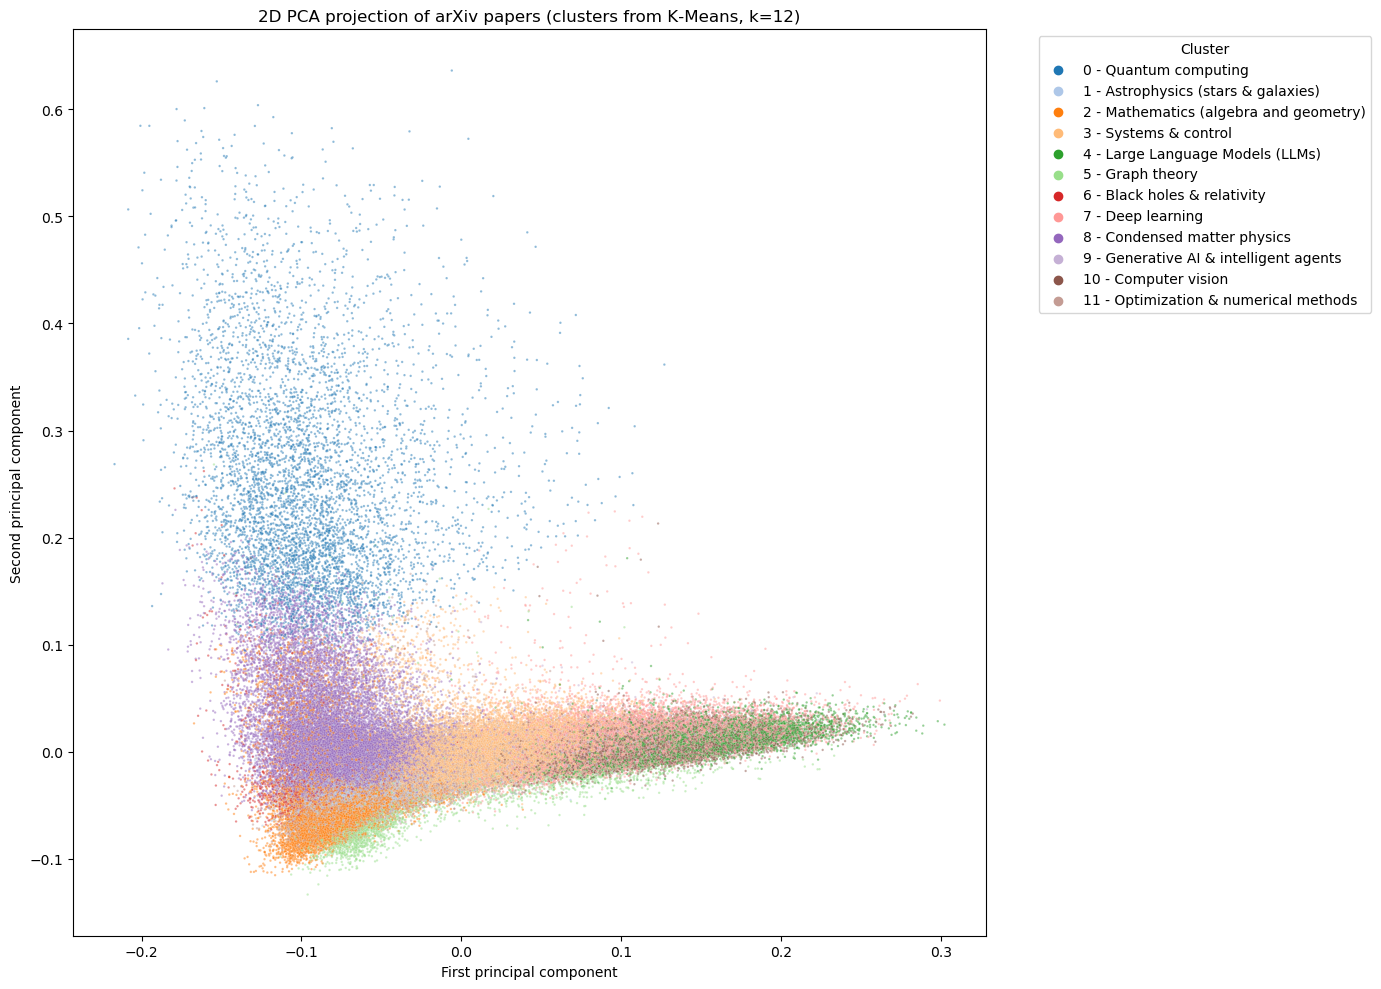

In [51]:
# reduces to 2 dimensions for plotting
pca_plot = PCA(n_components=2, random_state=38)
X_2d = pca_plot.fit_transform(X_reduced)

# prepares a DataFrame for seaborn
plot_df = pd.DataFrame({
    'x': X_2d[:, 0],
    'y': X_2d[:, 1],
     'cluster_label': df['cluster_legend']})


hue_order = [legend_labels[i] for i in sorted(legend_labels.keys())]

# the plot
plt.figure(figsize=(14, 10))
sns.scatterplot(data=plot_df, x='x', y='y', hue='cluster_label', hue_order=hue_order, palette=cluster_colors, alpha=0.5, s=3, legend='full')
plt.title('2D PCA projection of arXiv papers (clusters from K‑Means, k=12)')
plt.xlabel('First principal component')
plt.ylabel('Second principal component')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Cluster')
plt.tight_layout()
plt.show()



### TEMPORAL EVOLUTION BAR CHART

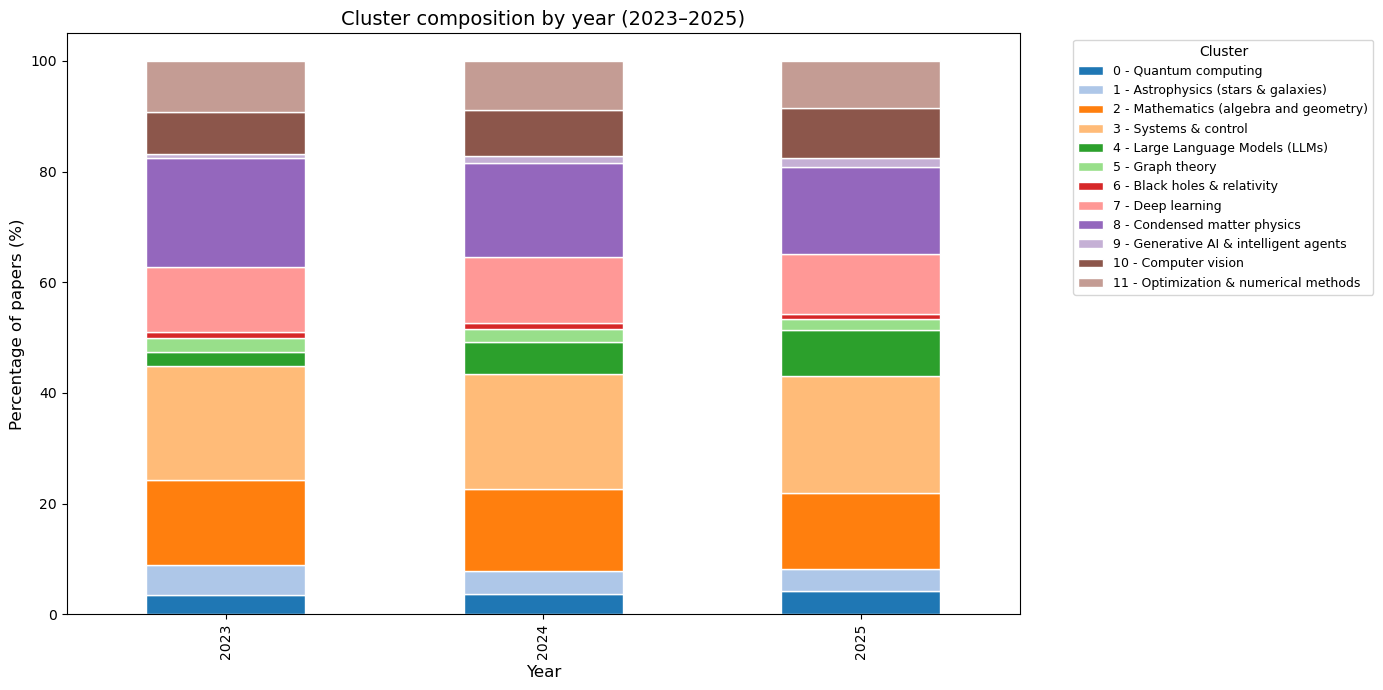

Percentage of papers per cluster each year (by cluster number):
cluster    0     1      2      3     4     5     6      7      8     9     10  \
year                                                                            
2023     3.49  5.41  15.28  20.76  2.53  2.38  1.09  11.88  19.69  0.69  7.66   
2024     3.57  4.30  14.70  20.82  5.91  2.34  0.92  12.04  16.95  1.27  8.40   
2025     4.24  3.90  13.75  21.24  8.17  2.05  1.00  10.77  15.74  1.55  9.15   

cluster    11  
year           
2023     9.14  
2024     8.79  
2025     8.46  


In [53]:
# groups by year and legend label
year_cluster_counts = df.groupby(['year', 'cluster_legend']).size().unstack(fill_value=0)

# reorders columns to follow natural cluster order 
ordered_legend = hue_order
year_cluster_counts = year_cluster_counts[ordered_legend]

# computes percentages
year_cluster_pct = year_cluster_counts.div(year_cluster_counts.sum(axis=1), axis=0) * 100

# plot stacked bar chart
ax = year_cluster_pct.plot(kind='bar', stacked=True, figsize=(14, 7), color=cluster_colors, edgecolor='white')
plt.title('Cluster composition by year (2023–2025)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Percentage of papers (%)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Cluster', fontsize=9)
plt.tight_layout()
plt.show()

year_cluster_counts_num = df.groupby(['year', 'cluster']).size().unstack(fill_value=0)
year_cluster_pct_num = year_cluster_counts_num.div(year_cluster_counts_num.sum(axis=1), axis=0) * 100

print("Percentage of papers per cluster each year (by cluster number):")
print(year_cluster_pct_num.round(2))

## 13. Conclusions and Recommendations

### Conclusions

The PCA projection (2D) forms a clear L-shape.

At the top I see quantum computing and astrophysics which are the most distinctive topics, away from the rest.

As I move down, condensed matter physics, black holes and mathematics appear, all partly overlapping. This makes sense because they share mathematical and physical language. 

The left arm of the L holds all the applied/computer science clusters: systems and control, LLMs, computer vision, optimisation and generative AI. They are tightly packed, meaning they are harder to separate visually but they stil form meaningful sub-groups.

To sum up, the analysis indicates: physical sciences live in one region and computational / AI topics live in another. 

Also, looking at the relative size of each cluster over time, I notice:

1. Clusters that are growing (in percentage of papers):
- Large Language Models: from 2.53% to 8.17%. Which is a huge jump and reflects the explosion of LLM research.
- Generative AI and intelligent agents: small but growing fast.
- Computer vision
- Systems and control
- Quantum computing
   
   
2. Clusters that are shrinking or losing share:
- Condensed matter physics: despite being the largest cluster, it is clearly declining. 
- Mathematics
- Astrophysics
- Deep Learning: slightly down but still large (around 11% of papers)
- Optimisation
- Black holes and relativity
- Graph theory 

### Recommendations

Based on the clustering and temporal analysis, the company should prioritize research collaborations in areas that are both growing and distinctive:

**1. Large Language Models (LLMs) and Generative AI**

These are the fastest growing clusters. Collaborating with universities, for example, or research groups working on LLMs, agents or generative models offer high relevance and long-term impact. 

**2. Computer Vision**

Steady growth, already a mature field with many applications. This might be a good candidate for applied research partnerships.

**3. Quantum Computing**

Smaller but very distinctive and visible. This is a strong candidate for high-impact area.

**4. Systems and Control**

Very large and slightly growing. It is a broad area so the company could target specific sub-fields like autonomous systems. 


As a secondary focus, I would recommend the areas that are large, stable or only slightly declining like condensed matter phyisics, mathematics and deep learning. Selective collaborations (like applied mathematics) could be valuable.

The scatter plot also suggests that the physical science clusters like quantum, astrophysics and black holes are the most unique. If the company wants to stand out, cooperating in those areas could give a distinctive profile.

This analysis gives the company a data-driven and quantitative overview of current scientific trends. If the company invests in the growing and distinctive clusters identified here, they can make informed decisions about academic collaboration.


### Limitations

The SVD retains only 8% of the explained variance. However, extensive testing showed that higher components consistently degraded clustering quality due to the curse of dimensionality, so 50 components represents the best trade-off found for this dataset.

I only used abstracts, not full-text papers. 

The sample is random and k=12 was chosen as a balance between silhouette score and interpretability. 

MDS (Multi-Dimensional Scaling) was also tested as an alternative 2D visualization method. However, it produced a less interpretable projection for this dataset and was therefore not included in the final analysis.

However, the overall picture is robust: AI-related topics are rising while some classical physics and maths topics are losing relative share.


## 14. Bibliography

arXiv.org submitters. (2024). arXiv Dataset [Data set]. Kaggle. https://doi.org/10.34740/KAGGLE/DSV/7548853

| Cluster | Topic | Key words | Papers | Share | Main arXiv category |
|---|---|---|---:|---:|---|
| 1 | Quantum computing | quantum, states, entanglement, qubits, circuit | 5,745 | 3.83% | quant-ph |
| 2 | Astrophysics (stars & galaxies) | galaxies, stars, mass, stellar, star | 6,639 | 4.43% | astro-ph.GA |
| 3 | Mathematics (algebra and geometry) | group, space, theory, finite, groups | 21,689 | 14.46% | math.NT |
| 4 | Systems & control | systems, model, control, framework, design | 31,467 | 20.98% | cs.RO |
| 5 | Large Language Models (LLMs) | llms, language, models, reasoning, tasks | 8,929 | 5.95% | cs.CL |
| 6 | Graph theory | graph, graphs, vertices, edges, node | 3,338 | 2.23% | math.CO |
| 7 | Black holes & relativity | black, hole, gravitational, gravity, horizon | 1,497 | 1.00% | gr-qc |
| 8 | Deep learning | data, learning, model, neural, training | 17,201 | 11.47% | cs.LG |
| 9 | Condensed matter physics | magnetic, phase, energy, spin, temperature | 25,759 | 17.17% | hep-ph |
| 10 | Generative AI & intelligent agents | ai, intelligence, artificial, generative, agents | 1,849 | 1.23% | cs.CY |
| 11 | Computer vision | image, images, segmentation, video, visual | 12,772 | 8.51% | cs.CV |
| 12 | Optimization & numerical methods | problem, solutions, convergence, optimization, numerical | 13,114 | 8.74% | math.OC |